# Neural Network from Scratch

## Cell 1 — The Neuron

A **neuron** is the fundamental building block of a neural network.

It computes:

$$z = \mathbf{W} \cdot \mathbf{X} + b$$

Where:
- $\mathbf{X}$ = input vector
- $\mathbf{W}$ = weights vector (one weight per input)
- $b$ = bias (a scalar)
- $z$ = linear output (called **pre-activation**)

The weights tell the neuron how much to "care about" each input.  
The bias lets the neuron fire even when all inputs are zero.

We use **numpy** for math — no TensorFlow, no Keras.

In [ ]:
import numpy as np

class Neuron:
    def __init__(self, n_inputs):
        # Random small weights for each input, and one bias
        # We subtract 0.5 to center them around zero (range: -0.5 to 0.5)
        self.weights = np.random.rand(n_inputs) - 0.5   # shape: (n_inputs,)
        self.bias    = np.random.rand(1)        - 0.5   # shape: (1,)

    def forward(self, X):
        """
        X: input vector of shape (n_inputs,)
        Returns z = W · X + b  (a single scalar)
        """
        z = np.dot(self.weights, X) + self.bias
        return z

# --- Quick test ---

neuron = Neuron(n_inputs=3)
sample_input = np.array([0.5, 0.2, 0.8])

z = neuron.forward(sample_input)
print(f"Weights : {neuron.weights}")
print(f"Bias    : {neuron.bias}")
print(f"Output z: {z}")   # z = w1*0.5 + w2*0.2 + w3*0.8 + b

Weights : [ 0.29736076  0.01824053 -0.27386203]
Bias    : [-0.30348236]
Output z: [-0.3702435]


## Cell 3 — Visualizing What a Neuron Does

Let's break down the computation `z = W · X + b` visually.

Each input $x_i$ is multiplied by its weight $w_i$.  
The **weighted contributions** $w_i \cdot x_i$ are then summed up, and the bias is added.

The bar chart below shows how much each input actually *contributes* to the final output.

C:\Users\admin\AppData\Local\Temp\ipykernel_17680\2761168996.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  bias         = float(neuron.bias)
C:\Users\admin\AppData\Local\Temp\ipykernel_17680\2761168996.py:49: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  axes[2].set_title(f"③ Weighted Contributions + Bias  →  z = {float(z):.4f}")
C:\Users\admin\AppData\Local\Temp\ipykernel_17680\2761168996.py:53: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  axes[2].axhline(

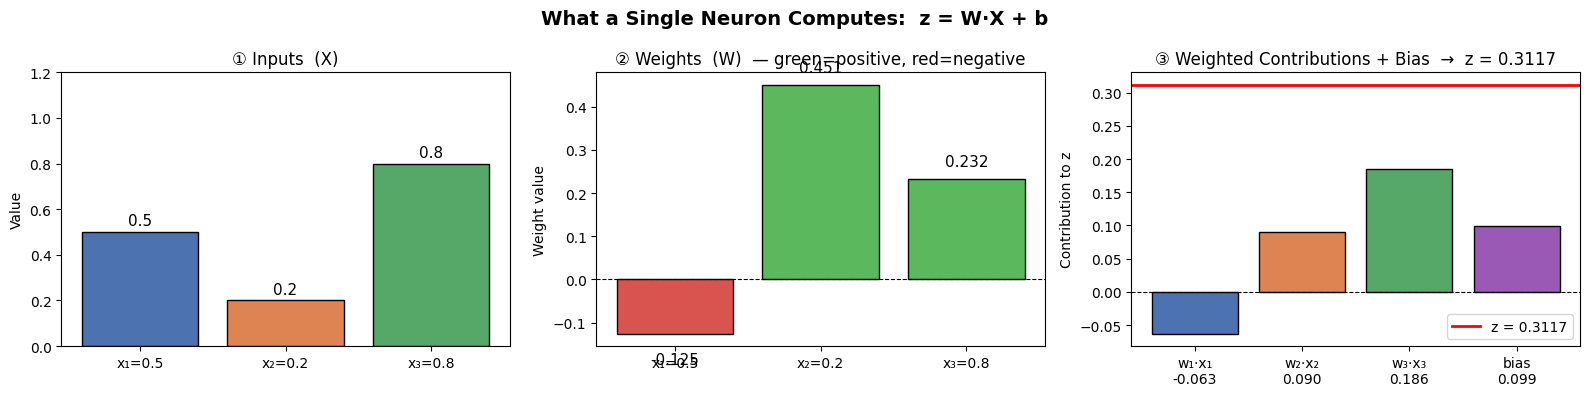


Manual check:  -0.0627 + 0.0901 + 0.1856 + 0.0987 = 0.3117
neuron.forward() returned: 0.3117


C:\Users\admin\AppData\Local\Temp\ipykernel_17680\2761168996.py:60: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"neuron.forward() returned: {float(z):.4f}")


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Reuse the neuron from Cell 2 ──────────────────────────────────────────────
np.random.seed(42)
neuron       = Neuron(n_inputs=3)
sample_input = np.array([0.5, 0.2, 0.8])
z            = neuron.forward(sample_input)

weights      = neuron.weights
bias         = float(neuron.bias)
contributions = weights * sample_input   # element-wise: wᵢ · xᵢ

labels = ['x₁=0.5', 'x₂=0.2', 'x₃=0.8']
colors = ['#4C72B0', '#DD8452', '#55A868']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("What a Single Neuron Computes:  z = W·X + b", fontsize=14, fontweight='bold')

# ── Plot 1: Inputs ────────────────────────────────────────────────────────────
axes[0].bar(labels, sample_input, color=colors, edgecolor='black')
axes[0].set_title("① Inputs  (X)")
axes[0].set_ylabel("Value")
axes[0].set_ylim(0, 1.2)
for i, v in enumerate(sample_input):
    axes[0].text(i, v + 0.03, f"{v}", ha='center', fontsize=11)

# ── Plot 2: Weights ───────────────────────────────────────────────────────────
bar_colors_w = ['#d9534f' if w < 0 else '#5cb85c' for w in weights]
axes[1].bar(labels, weights, color=bar_colors_w, edgecolor='black')
axes[1].set_title("② Weights  (W)  — green=positive, red=negative")
axes[1].set_ylabel("Weight value")
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
for i, v in enumerate(weights):
    axes[1].text(i, v + (0.03 if v >= 0 else -0.07), f"{v:.3f}", ha='center', fontsize=11)


# ── Plot 3: Weighted contributions + bias + z ─────────────────────────────────
bar_labels  = [f'w₁·x₁\n{contributions[0]:.3f}',
               f'w₂·x₂\n{contributions[1]:.3f}',
               f'w₃·x₃\n{contributions[2]:.3f}',
               f'bias\n{bias:.3f}']
bar_values  = list(contributions) + [bias]
bar_clrs    = ['#4C72B0', '#DD8452', '#55A868', '#9B59B6']
edge_colors = ['black'] * 4

axes[2].bar(bar_labels, bar_values, color=bar_clrs, edgecolor=edge_colors)
axes[2].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[2].set_title(f"③ Weighted Contributions + Bias  →  z = {float(z):.4f}")
axes[2].set_ylabel("Contribution to z")

# Annotate total z as a horizontal line
axes[2].axhline(float(z), color='red', linewidth=2, linestyle='-', label=f'z = {float(z):.4f}')
axes[2].legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f"\nManual check:  {contributions[0]:.4f} + {contributions[1]:.4f} + {contributions[2]:.4f} + {bias:.4f} = {sum(contributions)+bias:.4f}")
print(f"neuron.forward() returned: {float(z):.4f}")

## Cell 4 — Why Do We Need Activation Functions? (ReLU)

Right now, `z = W·X + b` is a **linear** operation.  
If you stack many neurons doing only linear math, the whole network collapses into a single linear equation — it can't learn complex patterns.

We fix this by passing `z` through a **non-linear activation function**.

### ReLU — Rectified Linear Unit

$$\text{ReLU}(z) = \max(0, z)$$

- If `z > 0` → output is `z` (pass it through)
- If `z ≤ 0` → output is `0` (kill it)

**Why it works:** It introduces non-linearity while being dead simple to compute and differentiate.  
**Intuition:** The neuron "fires" only when its input is positive — like a biological neuron.

The derivative (used during backprop) is:
$$\text{ReLU}'(z) = \begin{cases} 1 & \text{if } z > 0 \\ 0 & \text{if } z \leq 0 \end{cases}$$

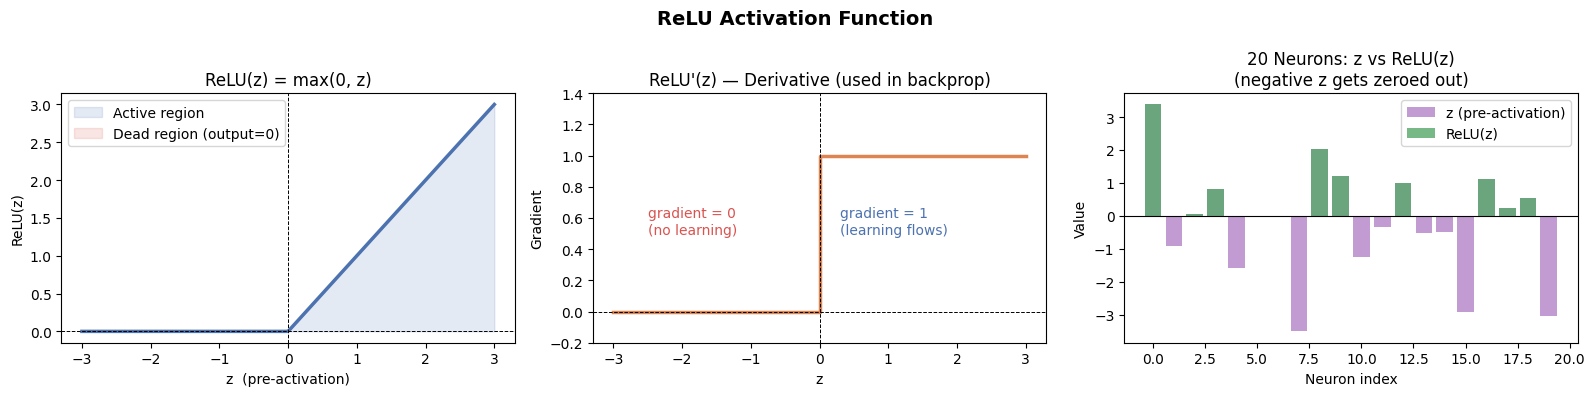

In [3]:
def ReLU(z):
    return np.maximum(0, z)

def ReLU_derivative(z):
    return (z > 0).astype(float)   # 1 where z>0, else 0

z_range = np.linspace(-3, 3, 300)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("ReLU Activation Function", fontsize=14, fontweight='bold')

# ── Plot 1: ReLU curve ────────────────────────────────────────────────────────
axes[0].plot(z_range, ReLU(z_range), color='#4C72B0', linewidth=2.5)
axes[0].axhline(0, color='black', linewidth=0.7, linestyle='--')
axes[0].axvline(0, color='black', linewidth=0.7, linestyle='--')
axes[0].fill_between(z_range, 0, ReLU(z_range), where=(z_range > 0), alpha=0.15, color='#4C72B0', label='Active region')
axes[0].fill_between(z_range, 0, ReLU(z_range), where=(z_range <= 0), alpha=0.15, color='#d9534f',  label='Dead region (output=0)')
axes[0].set_title("ReLU(z) = max(0, z)")
axes[0].set_xlabel("z  (pre-activation)")
axes[0].set_ylabel("ReLU(z)")
axes[0].legend()

# ── Plot 2: ReLU derivative ───────────────────────────────────────────────────
axes[1].step(z_range, ReLU_derivative(z_range), color='#DD8452', linewidth=2.5, where='post')
axes[1].axhline(0, color='black', linewidth=0.7, linestyle='--')
axes[1].axvline(0, color='black', linewidth=0.7, linestyle='--')
axes[1].set_title("ReLU'(z) — Derivative (used in backprop)")
axes[1].set_xlabel("z")
axes[1].set_ylabel("Gradient")
axes[1].set_ylim(-0.2, 1.4)
axes[1].text(-2.5, 0.5, "gradient = 0\n(no learning)", color='#d9534f', fontsize=10)
axes[1].text( 0.3, 0.5, "gradient = 1\n(learning flows)", color='#4C72B0', fontsize=10)

# ── Plot 3: Before vs After ReLU for sample neuron outputs ───────────────────
np.random.seed(7)
raw_z   = np.random.randn(20) * 2        # 20 random pre-activation values
after   = ReLU(raw_z)
x_idx   = np.arange(20)

axes[2].bar(x_idx, raw_z,  label='z (pre-activation)',  alpha=0.6, color='#9B59B6')
axes[2].bar(x_idx, after,  label='ReLU(z)',              alpha=0.8, color='#55A868')
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_title("20 Neurons: z vs ReLU(z)\n(negative z gets zeroed out)")
axes[2].set_xlabel("Neuron index")
axes[2].set_ylabel("Value")
axes[2].legend()

plt.tight_layout()
plt.show()

---
## Cell 5 — From One Neuron to a Layer

A single neuron computes: $z = \mathbf{W} \cdot \mathbf{X} + b$

A **layer** stacks `n_neurons` neurons, each with its own weights, all reading the **same input** simultaneously.

$$Z = \mathbf{W} \cdot X + \mathbf{b}$$

| Symbol | Shape | Meaning |
|--------|-------|---------|
| $X$ | `(n_inputs, m)` | m input samples, each with n_inputs features |
| $\mathbf{W}$ | `(n_neurons, n_inputs)` | one row of weights per neuron |
| $\mathbf{b}$ | `(n_neurons, 1)` | one bias per neuron |
| $Z$ | `(n_neurons, m)` | raw output of every neuron for every sample |
| $A$ | `(n_neurons, m)` | after applying ReLU: $A = \text{ReLU}(Z)$ |

**Why this shape?**  
Each row of $\mathbf{W}$ belongs to one neuron. When we do $\mathbf{W} \cdot X$, each row (neuron) computes its dot product with every column (sample) of $X$ at once — that's the matrix multiplication doing all the work in one shot.

In [4]:
class Layer:
    def __init__(self, n_inputs, n_neurons):
        # W shape: (n_neurons, n_inputs) — one row of weights per neuron
        self.W = np.random.rand(n_neurons, n_inputs) - 0.5
        # b shape: (n_neurons, 1) — one bias per neuron
        self.b = np.random.rand(n_neurons, 1) - 0.5

    def forward(self, X):
        """
        X: shape (n_inputs, m) — m samples
        Z = W · X + b
        Returns Z of shape (n_neurons, m)
        """
        Z = self.W.dot(X) + self.b   # matrix multiply + broadcast bias
        return Z

# ── Quick test ────────────────────────────────────────────────────────────────
np.random.seed(42)

# Imagine 4 inputs, 3 neurons, 5 samples
layer        = Layer(n_inputs=4, n_neurons=3)
X_sample     = np.random.rand(4, 5)   # 4 features, 5 samples

Z = layer.forward(X_sample)
A = ReLU(Z)

print("Weight matrix W — shape:", layer.W.shape)
print(layer.W)
print("\nBias vector b — shape:", layer.b.shape)
print(layer.b)
print("\nInput X — shape:", X_sample.shape)
print("\nPre-activation Z = W·X + b — shape:", Z.shape)
print(Z)
print("\nPost-activation A = ReLU(Z) — shape:", A.shape)
print(A)

Weight matrix W — shape: (3, 4)
[[-0.12545988  0.45071431  0.23199394  0.09865848]
 [-0.34398136 -0.34400548 -0.44191639  0.36617615]
 [ 0.10111501  0.20807258 -0.47941551  0.46990985]]

Bias vector b — shape: (3, 1)
[[ 0.33244264]
 [-0.28766089]
 [-0.31817503]]

Input X — shape: (4, 5)

Pre-activation Z = W·X + b — shape: (3, 5)
[[ 0.82729911  0.42029108  0.5239977   0.67442759  0.60750634]
 [-0.68574306 -0.46609845 -0.77209496 -0.47661086 -0.21166464]
 [-0.26325449 -0.27398247 -0.42029057 -0.03639112  0.23765922]]

Post-activation A = ReLU(Z) — shape: (3, 5)
[[0.82729911 0.42029108 0.5239977  0.67442759 0.60750634]
 [0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.23765922]]


## Cell 7 — Visualizing a Layer

Three things to see:
1. **Matrix multiplication diagram** — how W, X, and Z relate in shape
2. **Heatmap of Z** — raw pre-activation outputs (can be negative)
3. **Heatmap of A = ReLU(Z)** — after activation (negatives zeroed out)

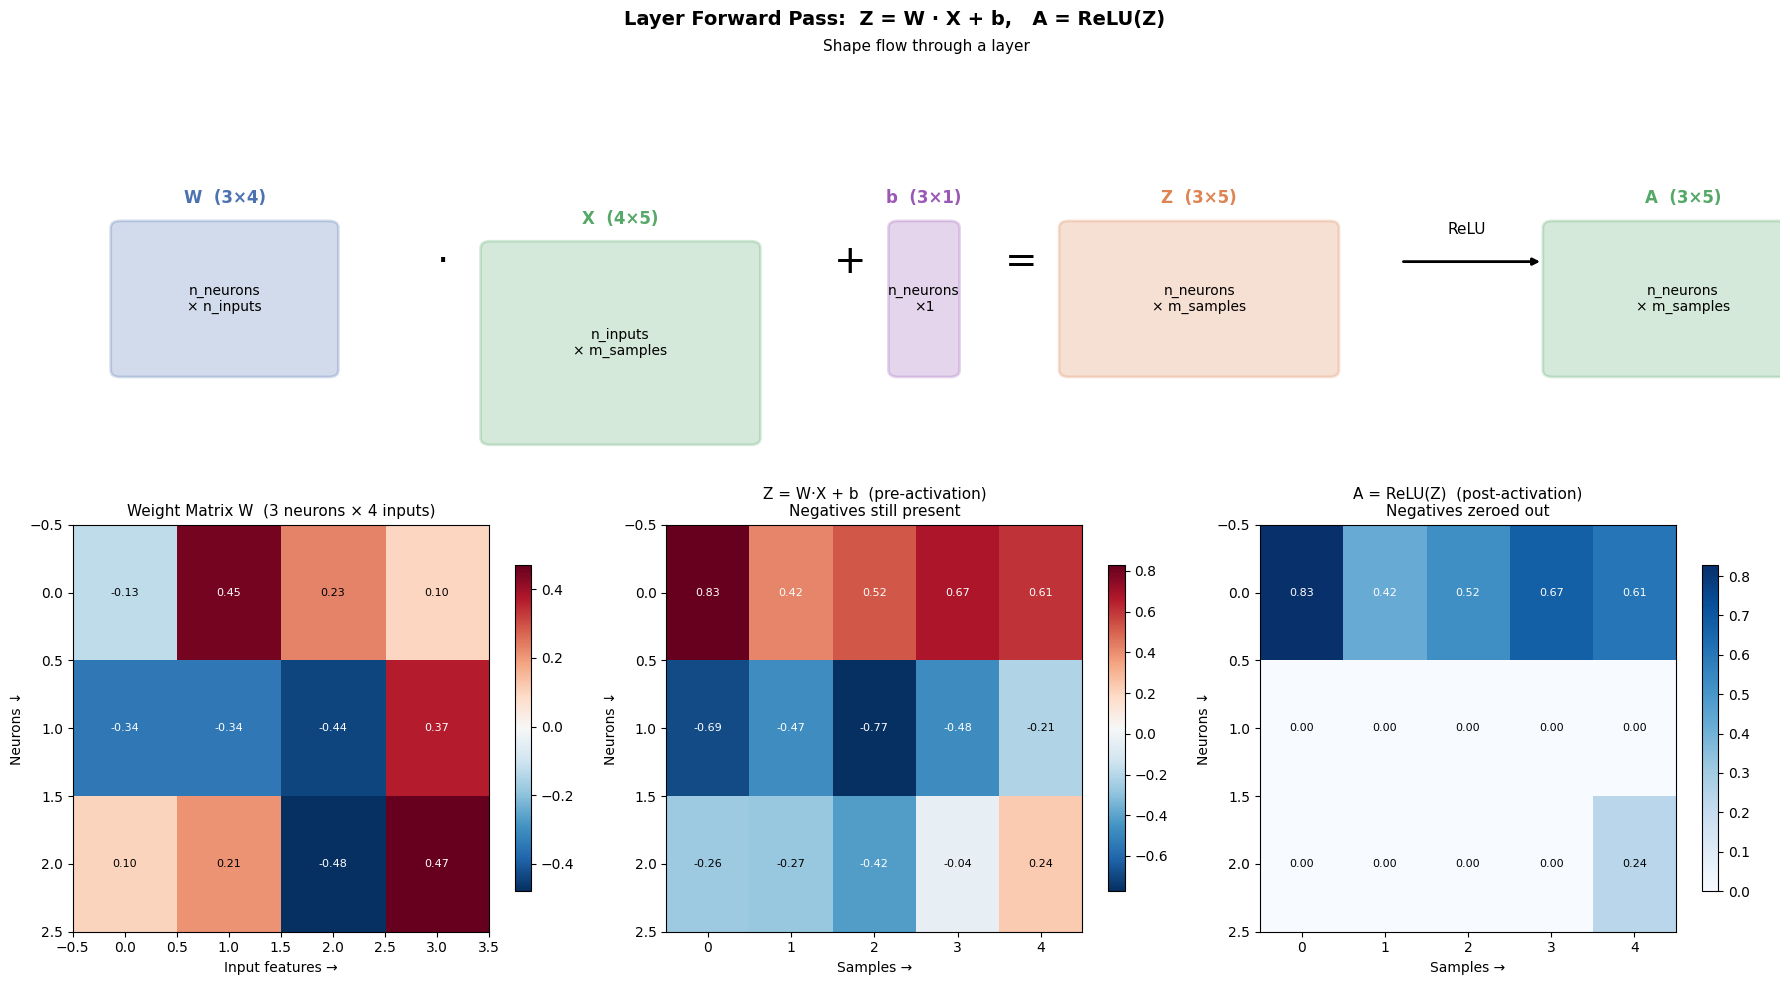

Negative values in Z: 9  →  after ReLU in A: 0
ReLU zeroed out 9 out of 15 values (60%)


In [5]:
fig = plt.figure(figsize=(18, 10))
fig.suptitle("Layer Forward Pass:  Z = W · X + b,   A = ReLU(Z)", fontsize=14, fontweight='bold')

# ════════════════════════════════════════════════════════════════════════════════
# TOP ROW — Matrix multiplication diagram
# ════════════════════════════════════════════════════════════════════════════════
ax_diag = fig.add_subplot(2, 3, (1, 3))
ax_diag.set_xlim(0, 18)
ax_diag.set_ylim(0, 6)
ax_diag.axis('off')

def draw_matrix(ax, x, y, rows, cols, label, sublabel, color):
    w, h = cols * 0.55, rows * 0.7
    rect = mpatches.FancyBboxPatch((x, y), w, h,
                                    boxstyle="round,pad=0.1",
                                    linewidth=2, edgecolor=color,
                                    facecolor=color, alpha=0.25)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h + 0.3, label,    ha='center', va='bottom', fontsize=12, fontweight='bold', color=color)
    ax.text(x + w/2, y + h/2,     sublabel, ha='center', va='center',  fontsize=10, color='black')

# W: (3 neurons × 4 inputs)
draw_matrix(ax_diag, 0.5, 1.5, rows=3, cols=4, label="W  (3×4)", sublabel="n_neurons\n× n_inputs", color='#4C72B0')
# dot symbol
ax_diag.text(3.9, 3.1, "·", fontsize=28, ha='center', va='center', color='black')
# X: (4 inputs × 5 samples)
draw_matrix(ax_diag, 4.4, 0.5, rows=4, cols=5, label="X  (4×5)", sublabel="n_inputs\n× m_samples", color='#55A868')
# + symbol
ax_diag.text(8.2, 3.1, "+", fontsize=28, ha='center', va='center', color='black')
# b: (3 neurons × 1)
draw_matrix(ax_diag, 8.7, 1.5, rows=3, cols=1, label="b  (3×1)", sublabel="n_neurons\n×1", color='#9B59B6')
# = symbol
ax_diag.text(10.0, 3.1, "=", fontsize=28, ha='center', va='center', color='black')
# Z: (3 neurons × 5 samples)
draw_matrix(ax_diag, 10.5, 1.5, rows=3, cols=5, label="Z  (3×5)", sublabel="n_neurons\n× m_samples", color='#DD8452')
# ReLU arrow
ax_diag.annotate("", xy=(15.5, 3.1), xytext=(14.0, 3.1),
                 arrowprops=dict(arrowstyle="-|>", color='black', lw=2))
ax_diag.text(14.7, 3.5, "ReLU", ha='center', fontsize=11, color='black')
# A: (3 neurons × 5 samples)
draw_matrix(ax_diag, 15.6, 1.5, rows=3, cols=5, label="A  (3×5)", sublabel="n_neurons\n× m_samples", color='#55A868')

ax_diag.set_title("Shape flow through a layer", fontsize=11, pad=10)

# ════════════════════════════════════════════════════════════════════════════════
# BOTTOM ROW — Heatmaps of W, Z, and A
# ════════════════════════════════════════════════════════════════════════════════
ax_w = fig.add_subplot(2, 3, 4)
ax_z = fig.add_subplot(2, 3, 5)
ax_a = fig.add_subplot(2, 3, 6)

# Heatmap helper
def heatmap(ax, data, title, xlabel, ylabel, cmap, show_val=True):
    im = ax.imshow(data, cmap=cmap, aspect='auto')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    plt.colorbar(im, ax=ax, shrink=0.8)
    if show_val:
        for r in range(data.shape[0]):
            for c in range(data.shape[1]):
                ax.text(c, r, f"{data[r, c]:.2f}", ha='center', va='center',
                        fontsize=8, color='white' if abs(data[r,c]) > 0.3 else 'black')

heatmap(ax_w, layer.W,
        title="Weight Matrix W  (3 neurons × 4 inputs)",
        xlabel="Input features →", ylabel="Neurons ↓",
        cmap='RdBu_r')

heatmap(ax_z, Z,
        title="Z = W·X + b  (pre-activation)\nNegatives still present",
        xlabel="Samples →", ylabel="Neurons ↓",
        cmap='RdBu_r')

heatmap(ax_a, A,
        title="A = ReLU(Z)  (post-activation)\nNegatives zeroed out",
        xlabel="Samples →", ylabel="Neurons ↓",
        cmap='Blues')

plt.tight_layout()
plt.show()

# Summary
neg_z = np.sum(Z < 0)
neg_a = np.sum(A < 0)
print(f"Negative values in Z: {neg_z}  →  after ReLU in A: {neg_a}")
print(f"ReLU zeroed out {neg_z} out of {Z.size} values ({100*neg_z/Z.size:.0f}%)")

---
## Cell 8 — Why Does ReLU Actually Help?

### The Real Problem: Stacking Linear Layers is Useless Without Activation

Consider two layers with no activation:

$$Z^{[2]} = W^{[2]} \cdot (W^{[1]} \cdot X + b^{[1]}) + b^{[2]}$$

Expand it:

$$Z^{[2]} = \underbrace{(W^{[2]} W^{[1]})}_{\text{just a new matrix } W'} \cdot X + \underbrace{(W^{[2]} b^{[1]} + b^{[2]})}_{\text{just a new bias } b'}$$

**No matter how many layers you stack without activation, it always collapses to:** $Z = W' \cdot X + b'$

That's just **one linear layer**. The network can never learn curves, boundaries, or complex patterns — only straight lines.

### What ReLU Does

ReLU **breaks linearity** by treating positive and negative regions differently:
- When $z > 0$: neuron is **active**, gradient flows, the network can learn
- When $z \leq 0$: neuron is **silent** (output = 0), it's effectively removed from the computation

This means different neurons activate for different inputs — each neuron **specializes** in a region of the input space.

### Three Visualizations Below:
1. **Linear vs ReLU network** fitting a non-linear curve — linear fails, ReLU succeeds
2. **Proof of linear collapse** — two linear layers = one linear layer
3. **Neuron specialization** — each neuron "owns" a different region of the input

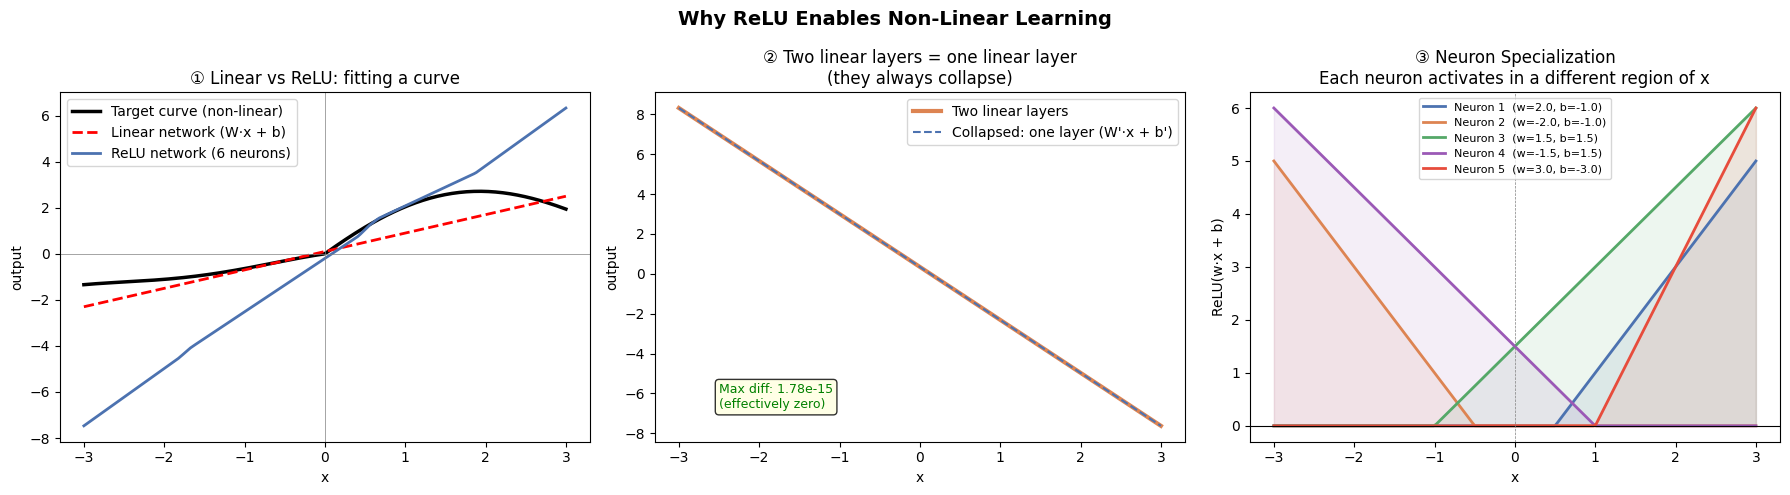

In [6]:
np.random.seed(0)
x = np.linspace(-3, 3, 200)

# ════════════════════════════════════════════════════════════════════════════════
# VIZ 1 — Linear network vs ReLU network fitting a curve
# ════════════════════════════════════════════════════════════════════════════════

# Target: a non-linear curve (bent/curved shape)
y_target = np.where(x < 0, -0.5 * x, 1.5 * x) - 0.3 * x**2 + np.sin(x)

# Linear network output (just W·x + b — always a straight line no matter weights)
W_lin, b_lin = 0.8, 0.1
y_linear = W_lin * x + b_lin

# ReLU network: 6 hidden neurons, manually tuned to show piecewise fitting
# Each neuron fires in a different region — together they approximate the curve
def relu_network(x, W1, b1, W2, b2):
    # Hidden layer: (6,) neurons
    Z1 = np.outer(W1, x) + b1[:, None]   # (6, 200)
    A1 = ReLU(Z1)                          # (6, 200)
    # Output: scalar per input
    out = W2 @ A1 + b2                     # (1, 200)
    return out.flatten()

W1 = np.array([ 1.2, -1.5,  0.8, -0.9,  1.1, -0.6])
b1 = np.array([-0.5,  1.0, -1.5,  0.5,  2.0, -1.0])
W2 = np.array([[ 0.9, -0.7,  1.1, -0.8,  0.5, -1.2]])
b2 = np.array([-0.1])
y_relu = relu_network(x, W1, b1, W2, b2)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Why ReLU Enables Non-Linear Learning", fontsize=14, fontweight='bold')

ax = axes[0]
ax.plot(x, y_target, 'k-',       lw=2.5, label='Target curve (non-linear)')
ax.plot(x, y_linear, 'r--',      lw=2,   label='Linear network (W·x + b)')
ax.plot(x, y_relu,   '#4C72B0',  lw=2,   label='ReLU network (6 neurons)')
ax.set_title("① Linear vs ReLU: fitting a curve")
ax.set_xlabel("x")
ax.set_ylabel("output")
ax.legend()
ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)

# ════════════════════════════════════════════════════════════════════════════════
# VIZ 2 — Proof: two linear layers = one linear layer
# ════════════════════════════════════════════════════════════════════════════════
ax = axes[1]

np.random.seed(5)
W1_l = np.random.randn(4, 1)     # Layer 1: 1 input → 4 neurons
b1_l = np.random.randn(4, 1)
W2_l = np.random.randn(1, 4)     # Layer 2: 4 neurons → 1 output
b2_l = np.random.randn(1, 1)

x_col = x.reshape(1, -1)         # (1, 200)

# Two separate linear layers (NO activation between them)
Z1_l  = W1_l @ x_col + b1_l     # (4, 200)
Z2_l  = W2_l @ Z1_l  + b2_l     # (1, 200) — two layer result

# Collapsed into one equivalent layer: W' = W2·W1,  b' = W2·b1 + b2
W_collapsed = W2_l @ W1_l        # (1, 1)
b_collapsed = W2_l @ b1_l + b2_l # (1, 1)
Z_collapsed = W_collapsed @ x_col + b_collapsed  # (1, 200)

ax.plot(x, Z2_l.flatten(),       color='#DD8452', lw=3,   label='Two linear layers')
ax.plot(x, Z_collapsed.flatten(), color='#4C72B0', lw=1.5, linestyle='--', label='Collapsed: one layer (W\'·x + b\')')
ax.set_title("② Two linear layers = one linear layer\n(they always collapse)")
ax.set_xlabel("x")
ax.set_ylabel("output")
ax.legend()

# Residual check
max_diff = np.max(np.abs(Z2_l - Z_collapsed))
ax.text(-2.5, ax.get_ylim()[0]*0.8, f"Max diff: {max_diff:.2e}\n(effectively zero)",
        fontsize=9, color='green',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# ════════════════════════════════════════════════════════════════════════════════
# VIZ 3 — Neuron specialization: each neuron fires in a different region
# ════════════════════════════════════════════════════════════════════════════════
ax = axes[2]

# 5 neurons with different weights/biases → each "owns" a different x region
neuron_W = [ 2.0, -2.0,  1.5, -1.5,  3.0]
neuron_b = [-1.0, -1.0,  1.5,  1.5, -3.0]
colors_n  = ['#4C72B0', '#DD8452', '#55A868', '#9B59B6', '#e74c3c']

for i, (w, b, c) in enumerate(zip(neuron_W, neuron_b, colors_n)):
    z_n = w * x + b
    a_n = ReLU(z_n)
    ax.plot(x, a_n, color=c, lw=2, label=f'Neuron {i+1}  (w={w}, b={b})')
    # Shade the active region
    ax.fill_between(x, 0, a_n, where=(a_n > 0), alpha=0.10, color=c)

ax.set_title("③ Neuron Specialization\nEach neuron activates in a different region of x")
ax.set_xlabel("x")
ax.set_ylabel("ReLU(w·x + b)")
ax.axhline(0, color='black', lw=0.8)
ax.axvline(0, color='gray',  lw=0.5, linestyle='--')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

---
## Cell 9 — The Full Network: Forward Pass

### Architecture

```
Input X  →  [Hidden Layer: ReLU]  →  [Output Layer: Softmax]  →  Probabilities
(784,m)       (128, m)                  (10, m)                    (10, m)
```

### Why Softmax on the Output?

ReLU is used in hidden layers. The output layer needs something different — we want **probabilities** (values between 0 and 1 that sum to 1), so we can say "this image is 87% likely to be a 3".

$$\text{Softmax}(z_i) = \frac{e^{z_i}}{\sum_{j} e^{z_j}}$$

- Takes a vector of raw scores (called **logits**) — any real number
- Converts them to probabilities that **sum to exactly 1**
- The largest logit gets the highest probability
- The `argmax` of the output = the predicted class

### Full Forward Pass (two-layer network)

$$Z^{[1]} = W^{[1]} \cdot X + b^{[1]}$$
$$A^{[1]} = \text{ReLU}(Z^{[1]})$$
$$Z^{[2]} = W^{[2]} \cdot A^{[1]} + b^{[2]}$$
$$A^{[2]} = \text{Softmax}(Z^{[2]})$$

$A^{[2]}$ is the final output — a probability distribution over all classes for each sample.

In [7]:
def softmax(Z):
    """
    Z: shape (n_classes, m)
    Subtracting max(Z) per column is a numerical stability trick —
    prevents e^(very large number) from overflowing to inf.
    The result is mathematically identical.
    """
    Z_stable = Z - np.max(Z, axis=0, keepdims=True)  # shift each column
    expZ = np.exp(Z_stable)
    return expZ / np.sum(expZ, axis=0, keepdims=True)


class NeuralNetwork:
    def __init__(self, n_inputs, n_hidden, n_outputs):
        """
        n_inputs  : number of features per sample (e.g. 784 for 28x28 images)
        n_hidden  : number of neurons in the hidden layer
        n_outputs : number of classes (e.g. 10 for digits 0-9)
        """
        self.hidden = Layer(n_inputs,  n_hidden)   # W1, b1
        self.output = Layer(n_hidden, n_outputs)   # W2, b2

    def forward(self, X):
        """
        X: shape (n_inputs, m)
        Returns all intermediate values — needed later for backprop.
        """
        # Hidden layer
        self.Z1 = self.hidden.W.dot(X) + self.hidden.b   # (n_hidden, m)
        self.A1 = ReLU(self.Z1)                           # (n_hidden, m)

        # Output layer
        self.Z2 = self.output.W.dot(self.A1) + self.output.b  # (n_outputs, m)
        self.A2 = softmax(self.Z2)                             # (n_outputs, m)

        return self.A2

    def predict(self, X):
        """Returns the predicted class index for each sample."""
        probs = self.forward(X)
        return np.argmax(probs, axis=0)   # index of highest probability


# ── Quick test ─────────────────────────────────────────────────────────────────
np.random.seed(42)

# Simulating MNIST-like data: 784 inputs, 128 hidden neurons, 10 output classes
nn = NeuralNetwork(n_inputs=784, n_hidden=128, n_outputs=10)

X_test    = np.random.rand(784, 5)   # 5 fake samples
probs     = nn.forward(X_test)
preds     = nn.predict(X_test)

print("Shape check:")
print(f"  Z1 (hidden pre-activation) : {nn.Z1.shape}")
print(f"  A1 (hidden post-ReLU)      : {nn.A1.shape}")
print(f"  Z2 (output pre-softmax)    : {nn.Z2.shape}")
print(f"  A2 (output probabilities)  : {nn.A2.shape}")
print(f"\nOutput probabilities for first sample (must sum to 1.0):")
print(np.round(probs[:, 0], 4))
print(f"Sum: {probs[:, 0].sum():.6f}")
print(f"\nPredicted classes for 5 samples: {preds}")

Shape check:
  Z1 (hidden pre-activation) : (128, 5)
  A1 (hidden post-ReLU)      : (128, 5)
  Z2 (output pre-softmax)    : (10, 5)
  A2 (output probabilities)  : (10, 5)

Output probabilities for first sample (must sum to 1.0):
[0.     0.     0.     0.     0.7064 0.0054 0.     0.2749 0.0134 0.    ]
Sum: 1.000000

Predicted classes for 5 samples: [4 5 7 5 5]


## Cell 11 — Visualizing Softmax + Full Network Data Flow

C:\Users\admin\AppData\Local\Temp\ipykernel_17680\153687752.py:94: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


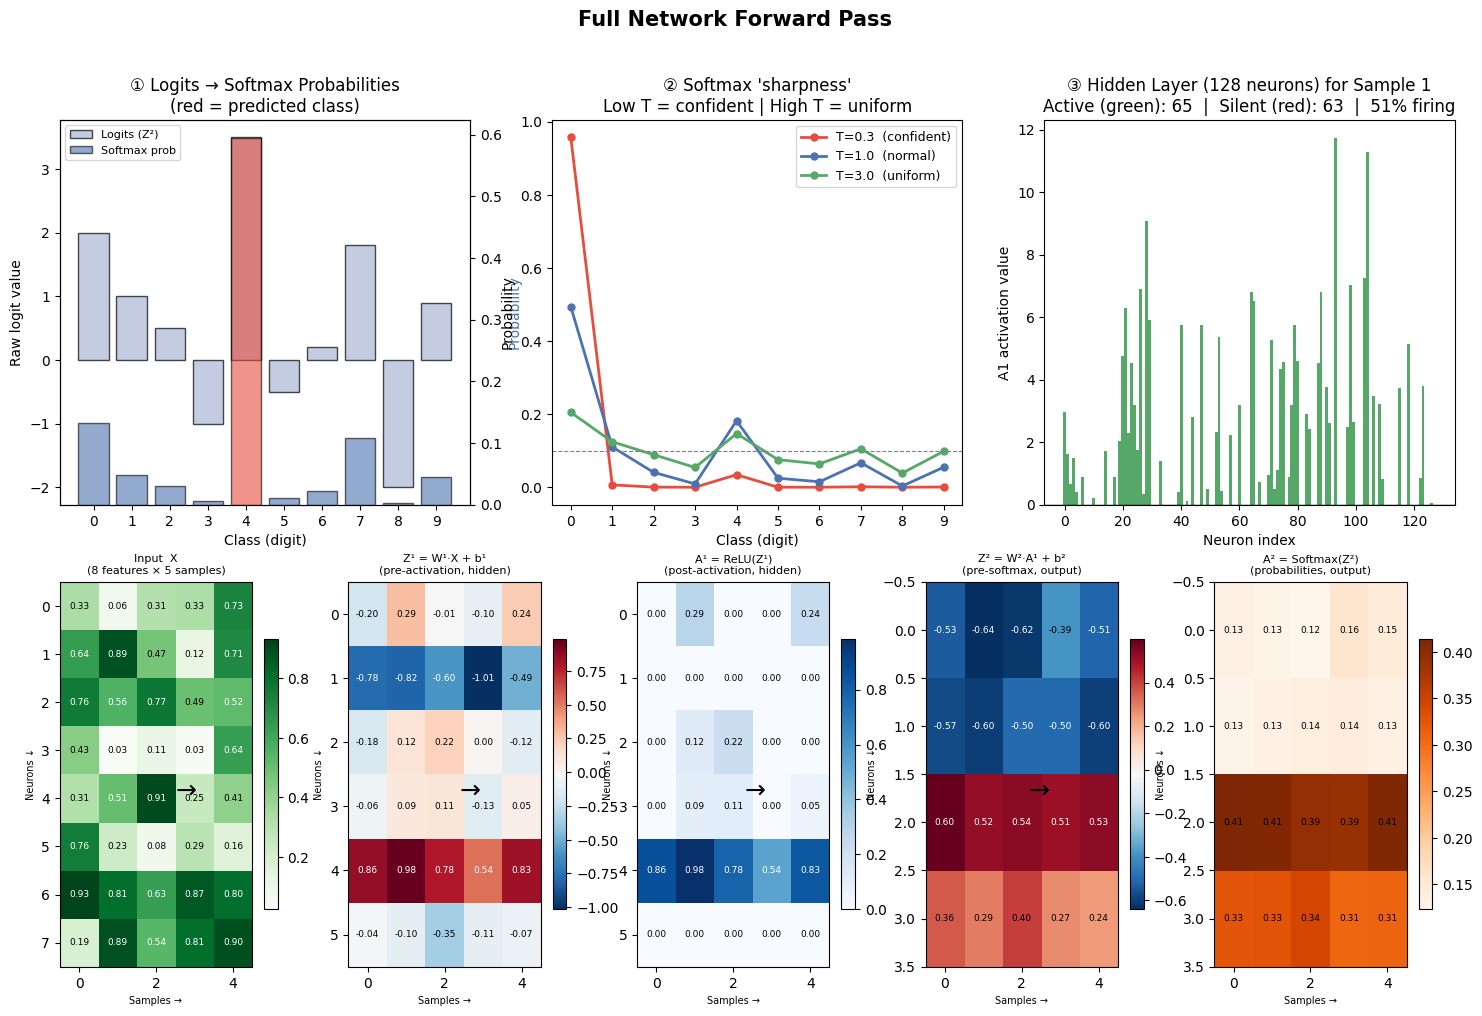

In [8]:
fig = plt.figure(figsize=(18, 11))
fig.suptitle("Full Network Forward Pass", fontsize=15, fontweight='bold')

# ════════════════════════════════════════════════════════════════════════════════
# TOP ROW — Softmax deep-dive (2 plots)
# ════════════════════════════════════════════════════════════════════════════════

# ── Plot 1: Raw logits vs Softmax probabilities ───────────────────────────────
ax1 = fig.add_subplot(2, 3, 1)
logits = np.array([2.0, 1.0, 0.5, -1.0, 3.5, -0.5, 0.2, 1.8, -2.0, 0.9])
probs_demo = softmax(logits.reshape(-1, 1)).flatten()
class_labels = [str(i) for i in range(10)]
bar_colors = ['#e74c3c' if i == np.argmax(probs_demo) else '#4C72B0' for i in range(10)]

ax1.bar(class_labels, logits, color='#aab7d4', edgecolor='black', label='Logits (Z²)', alpha=0.7)
ax1_twin = ax1.twinx()
ax1_twin.bar(class_labels, probs_demo, color=bar_colors, edgecolor='black', alpha=0.6, label='Softmax prob')
ax1_twin.set_ylabel("Probability", color='#4C72B0')
ax1.set_ylabel("Raw logit value")
ax1.set_xlabel("Class (digit)")
ax1.set_title("① Logits → Softmax Probabilities\n(red = predicted class)")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper left')

# ── Plot 2: How Softmax "sharpens" — temperature effect ──────────────────────
ax2 = fig.add_subplot(2, 3, 2)
base_logits = np.array([3.0, 1.5, 0.5, -1.0, 2.0, 0.0, -0.5, 1.0, -2.0, 0.8])
temps = [0.3, 1.0, 3.0]   # dividing logits by temperature — low=confident, high=uniform
colors_t = ['#e74c3c', '#4C72B0', '#55A868']
x_pos = np.arange(10)

for t, c in zip(temps, colors_t):
    p = softmax((base_logits / t).reshape(-1, 1)).flatten()
    ax2.plot(x_pos, p, 'o-', color=c, lw=2, markersize=5,
             label=f'T={t}  {"(confident)" if t<1 else "(uniform)" if t>1 else "(normal)"}')

ax2.set_xticks(x_pos)
ax2.set_xticklabels(class_labels)
ax2.set_xlabel("Class (digit)")
ax2.set_ylabel("Probability")
ax2.set_title("② Softmax 'sharpness'\nLow T = confident | High T = uniform")
ax2.legend(fontsize=9)
ax2.axhline(0.1, color='gray', lw=0.8, linestyle='--', label='Uniform (1/10)')

# ── Plot 3: Activation sparsity — how many hidden neurons actually fired ──────
ax3 = fig.add_subplot(2, 3, 3)
active_mask = (nn.A1[:, 0] > 0).astype(int)   # first sample, hidden layer
active_pct  = active_mask.mean() * 100
ax3.bar(range(len(active_mask)), nn.A1[:, 0],
        color=['#55A868' if v > 0 else '#d9534f' for v in nn.A1[:, 0]],
        width=1.0, edgecolor='none')
ax3.set_title(f"③ Hidden Layer (128 neurons) for Sample 1\n"
              f"Active (green): {active_mask.sum()}  |  Silent (red): {(1-active_mask).sum()}  |  {active_pct:.0f}% firing")
ax3.set_xlabel("Neuron index")
ax3.set_ylabel("A1 activation value")
ax3.axhline(0, color='black', lw=1)

# ════════════════════════════════════════════════════════════════════════════════
# BOTTOM ROW — Data flow heatmaps across the whole network
# ════════════════════════════════════════════════════════════════════════════════

# Use a smaller network for clarity: 8 inputs, 6 hidden, 4 output
np.random.seed(42)
nn_small = NeuralNetwork(n_inputs=8, n_hidden=6, n_outputs=4)
X_small  = np.random.rand(8, 5)
_        = nn_small.forward(X_small)

stages = [
    (X_small,        "Input  X\n(8 features × 5 samples)",    'Greens'),
    (nn_small.Z1,    "Z¹ = W¹·X + b¹\n(pre-activation, hidden)", 'RdBu_r'),
    (nn_small.A1,    "A¹ = ReLU(Z¹)\n(post-activation, hidden)",  'Blues'),
    (nn_small.Z2,    "Z² = W²·A¹ + b²\n(pre-softmax, output)",    'RdBu_r'),
    (nn_small.A2,    "A² = Softmax(Z²)\n(probabilities, output)",  'Oranges'),
]

for i, (data, title, cmap) in enumerate(stages):
    ax = fig.add_subplot(2, 5, 6 + i)
    im = ax.imshow(data, cmap=cmap, aspect='auto')
    ax.set_title(title, fontsize=8)
    ax.set_xlabel("Samples →", fontsize=7)
    ax.set_ylabel("Neurons ↓", fontsize=7)
    plt.colorbar(im, ax=ax, shrink=0.7)
    # Annotate cell values
    for r in range(data.shape[0]):
        for c in range(data.shape[1]):
            ax.text(c, r, f"{data[r,c]:.2f}", ha='center', va='center',
                    fontsize=6.5, color='white' if abs(data[r,c]) > 0.5 else 'black')

    # Arrow between stages
    if i < len(stages) - 1:
        fig.text(0.195 + i * 0.158, 0.27, '→', fontsize=18, ha='center', va='center', color='black')

plt.tight_layout()
plt.show()

---
## Cell 12 — Loss Function: Cross-Entropy

The network just made a prediction — a probability distribution over 10 classes.  
We need one number that answers: **how wrong is this prediction?**

That number is the **loss**.

### Why Not Just Use Accuracy?

Accuracy is either 0 or 1 per sample — not differentiable, so we can't compute gradients from it.  
We need a smooth, continuous function whose gradient tells us *which direction to nudge the weights*.

### Cross-Entropy Loss

For a single sample where the correct class is $y$:

$$L = -\log\left(A^{[2]}_y\right)$$

- $A^{[2]}_y$ is the **predicted probability for the correct class**
- If the network is confident and correct → probability close to 1 → $-\log(1) = 0$ → low loss ✓
- If the network is wrong → probability close to 0 → $-\log(0) = \infty$ → high loss ✗

Over $m$ samples:

$$\mathcal{L} = -\frac{1}{m} \sum_{i=1}^{m} \log\left(A^{[2]}_{y^{(i)}, i}\right)$$

**We only look at the probability assigned to the correct class — everything else is ignored.**  
If the network puts low probability on the right answer, it gets heavily penalized (log curve is steep near 0).

In [9]:
def cross_entropy_loss(A2, Y):
    """
    A2 : shape (n_classes, m) — predicted probabilities from softmax
    Y  : shape (m,)           — true class indices (e.g. [3, 7, 2, ...])

    For each sample i, we pick A2[Y[i], i] — the probability given to the correct class.
    Then we take -log of it and average over all samples.
    """
    m = Y.shape[0]
    # Clip to avoid log(0) = -inf blowing up
    correct_probs = A2[Y, np.arange(m)]          # shape (m,) — one prob per sample
    loss = -np.sum(np.log(correct_probs + 1e-8)) / m
    return loss


# ── Demo ──────────────────────────────────────────────────────────────────────
np.random.seed(42)
nn_demo = NeuralNetwork(n_inputs=784, n_hidden=128, n_outputs=10)

X_demo = np.random.rand(784, 6)
Y_demo = np.array([3, 7, 1, 0, 5, 9])   # true labels for 6 samples

A2_demo = nn_demo.forward(X_demo)
loss    = cross_entropy_loss(A2_demo, Y_demo)

print("Predicted probabilities (each column = one sample, rows = classes 0-9):")
print(np.round(A2_demo, 3))
print(f"\nTrue labels              : {Y_demo}")
print(f"Correct class probs      : {np.round(A2_demo[Y_demo, np.arange(6)], 4)}")
print(f"\nCross-entropy loss       : {loss:.4f}")
print(f"\nNote: random network → each class gets ~1/10 = 0.10 probability")
print(f"      -log(0.10) ≈ {-np.log(0.10):.4f}  ← expected loss for a random network")

Predicted probabilities (each column = one sample, rows = classes 0-9):
[[0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.   ]
 [0.    0.626 0.301 0.679 0.    0.581]
 [0.999 0.121 0.029 0.008 0.    0.419]
 [0.    0.    0.    0.    0.    0.   ]
 [0.001 0.253 0.669 0.313 1.    0.   ]
 [0.    0.    0.001 0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.   ]]

True labels              : [3 7 1 0 5 9]
Correct class probs      : [0.     0.2527 0.     0.     0.     0.    ]

Cross-entropy loss       : 15.0974

Note: random network → each class gets ~1/10 = 0.10 probability
      -log(0.10) ≈ 2.3026  ← expected loss for a random network


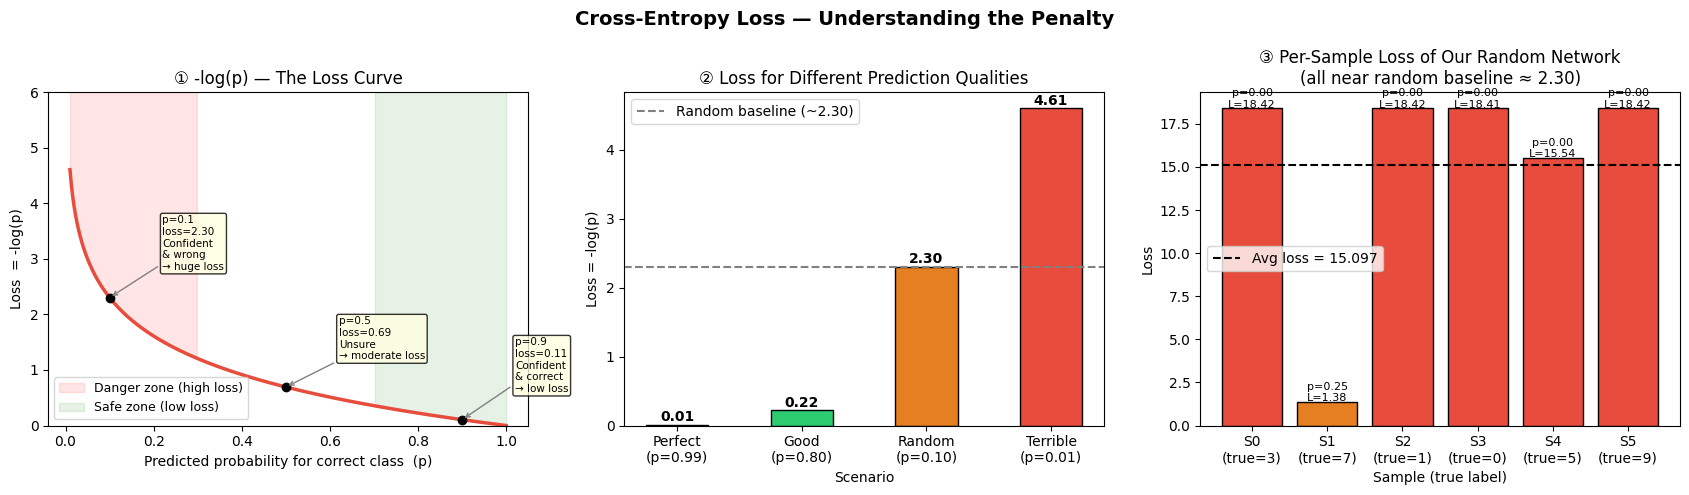

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Cross-Entropy Loss — Understanding the Penalty", fontsize=14, fontweight='bold')

# ── Plot 1: -log(p) curve ─────────────────────────────────────────────────────
ax = axes[0]
p = np.linspace(0.01, 1.0, 300)
ax.plot(p, -np.log(p), color='#e74c3c', lw=2.5)
ax.set_title("① -log(p) — The Loss Curve")
ax.set_xlabel("Predicted probability for correct class  (p)")
ax.set_ylabel("Loss  = -log(p)")
ax.set_ylim(0, 6)

# Annotate key points
for prob, label in [(0.9, "Confident\n& correct\n→ low loss"),
                    (0.5, "Unsure\n→ moderate loss"),
                    (0.1, "Confident\n& wrong\n→ huge loss")]:
    loss_val = -np.log(prob)
    ax.annotate(f"p={prob}\nloss={loss_val:.2f}\n{label}",
                xy=(prob, loss_val),
                xytext=(prob + 0.12, loss_val + 0.5),
                fontsize=7.5,
                arrowprops=dict(arrowstyle='->', color='gray'),
                bbox=dict(boxstyle='round,pad=0.2', facecolor='lightyellow', alpha=0.8))
    ax.plot(prob, loss_val, 'ko', markersize=6)

ax.fill_between(p, -np.log(p), 6, where=(p < 0.3), alpha=0.1, color='red',   label='Danger zone (high loss)')
ax.fill_between(p, -np.log(p), 6, where=(p > 0.7), alpha=0.1, color='green', label='Safe zone (low loss)')
ax.legend(fontsize=9)

# ── Plot 2: Loss per sample — comparing good vs bad prediction ────────────────
ax = axes[1]
scenarios = {
    'Perfect\n(p=0.99)':   0.99,
    'Good\n(p=0.80)':      0.80,
    'Random\n(p=0.10)':    0.10,
    'Terrible\n(p=0.01)':  0.01,
}
s_labels = list(scenarios.keys())
s_losses = [-np.log(v) for v in scenarios.values()]
s_colors = ['#27ae60', '#2ecc71', '#e67e22', '#e74c3c']

bars = ax.bar(s_labels, s_losses, color=s_colors, edgecolor='black', width=0.5)
ax.set_title("② Loss for Different Prediction Qualities")
ax.set_ylabel("Loss = -log(p)")
ax.set_xlabel("Scenario")
for bar, loss_v in zip(bars, s_losses):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f"{loss_v:.2f}", ha='center', fontsize=10, fontweight='bold')
ax.axhline(-np.log(0.1), color='gray', linestyle='--', lw=1.5, label='Random baseline (~2.30)')
ax.legend()

# ── Plot 3: Our network's loss — per sample breakdown ────────────────────────
ax = axes[2]
correct_probs = A2_demo[Y_demo, np.arange(6)]
per_sample_loss = -np.log(correct_probs + 1e-8)
sample_colors = ['#27ae60' if p > 0.5 else '#e67e22' if p > 0.2 else '#e74c3c'
                 for p in correct_probs]

bars = ax.bar([f"S{i}\n(true={Y_demo[i]})" for i in range(6)],
              per_sample_loss, color=sample_colors, edgecolor='black')
for bar, lv, cp in zip(bars, per_sample_loss, correct_probs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"p={cp:.2f}\nL={lv:.2f}", ha='center', fontsize=8)

ax.axhline(loss, color='black', linestyle='--', lw=1.5, label=f'Avg loss = {loss:.3f}')
ax.set_title("③ Per-Sample Loss of Our Random Network\n(all near random baseline ≈ 2.30)")
ax.set_ylabel("Loss")
ax.set_xlabel("Sample (true label)")
ax.legend()

plt.tight_layout()
plt.show()

---
## Cell 14 — Backpropagation: The Core Idea

We have a loss $\mathcal{L}$. We want to know:  
**"If I nudge this weight slightly, how much does the loss change?"**

That's a derivative — specifically $\frac{\partial \mathcal{L}}{\partial W}$.

We can't compute it directly because $W$ doesn't connect to $\mathcal{L}$ in one step.  
The path is: $W \rightarrow Z \rightarrow A \rightarrow \mathcal{L}$

This is where the **Chain Rule** comes in:

$$\frac{\partial \mathcal{L}}{\partial W} = \frac{\partial \mathcal{L}}{\partial A} \cdot \frac{\partial A}{\partial Z} \cdot \frac{\partial Z}{\partial W}$$

We walk **backwards** through the network, multiplying gradients as we go.

---

### Deriving Each Gradient Step by Step

**Step 1 — Gradient at output layer** (Softmax + Cross-Entropy combined):

The derivative of cross-entropy loss through softmax simplifies beautifully to:

$$dZ^{[2]} = A^{[2]} - Y_{\text{one-hot}}$$

Just subtract 1 from the probability of the correct class. That's it.

**Step 2 — Gradients of W2 and b2:**

$$dW^{[2]} = \frac{1}{m} \, dZ^{[2]} \cdot A^{[1]T}$$

$$db^{[2]} = \frac{1}{m} \sum dZ^{[2]}$$

**Step 3 — Push gradient back through to hidden layer:**

$$dA^{[1]} = W^{[2]T} \cdot dZ^{[2]}$$

$$dZ^{[1]} = dA^{[1]} \odot \text{ReLU}'(Z^{[1]})$$

$\odot$ means element-wise multiply. ReLU's derivative just passes the gradient where $Z^{[1]} > 0$ and blocks it (multiplies by 0) where $Z^{[1]} \leq 0$.

**Step 4 — Gradients of W1 and b1:**

$$dW^{[1]} = \frac{1}{m} \, dZ^{[1]} \cdot X^{T}$$

$$db^{[1]} = \frac{1}{m} \sum dZ^{[1]}$$

---

### Gradient Descent Update

Once we have all gradients, we nudge every weight opposite to the gradient direction (downhill on the loss surface):

$$W := W - \alpha \cdot dW$$
$$b := b - \alpha \cdot db$$

$\alpha$ is the **learning rate** — how big a step to take. Too large → overshoot. Too small → slow.

In [12]:
def one_hot(Y, n_classes):
    """
    Converts label vector to one-hot matrix.
    Y = [3, 7, 1]  →  each label becomes a column with a single 1 at that row.
    Shape: (n_classes, m)
    """
    m = Y.shape[0]
    one_hot_Y = np.zeros((n_classes, m))
    one_hot_Y[Y, np.arange(m)] = 1
    return one_hot_Y


def backward(nn, X, Y, alpha):
    """
    Performs one full backward pass + weight update.

    nn    : NeuralNetwork instance (must have run forward() first)
    X     : input,  shape (n_inputs, m)
    Y     : labels, shape (m,)
    alpha : learning rate
    """
    m = X.shape[1]
    n_classes = nn.A2.shape[0]

    # ── Step 1: Output layer gradient ──────────────────────────────────────
    # Combined softmax + cross-entropy derivative: dZ2 = A2 - Y_one_hot
    Y_oh  = one_hot(Y, n_classes)           # (n_classes, m)
    dZ2   = nn.A2 - Y_oh                    # (n_classes, m)

    # ── Step 2: Gradients for W2, b2 ───────────────────────────────────────
    dW2   = (1/m) * dZ2.dot(nn.A1.T)        # (n_classes, n_hidden)
    db2   = (1/m) * np.sum(dZ2, axis=1, keepdims=True)  # (n_classes, 1)

    # ── Step 3: Push gradient back through to hidden layer ─────────────────
    dA1   = nn.output.W.T.dot(dZ2)          # (n_hidden, m)
    dZ1   = dA1 * ReLU_derivative(nn.Z1)    # (n_hidden, m) — blocked where Z1 ≤ 0

    # ── Step 4: Gradients for W1, b1 ───────────────────────────────────────
    dW1   = (1/m) * dZ1.dot(X.T)            # (n_hidden, n_inputs)
    db1   = (1/m) * np.sum(dZ1, axis=1, keepdims=True)  # (n_hidden, 1)

    # ── Step 5: Update all weights ─────────────────────────────────────────
    nn.output.W -= alpha * dW2
    nn.output.b -= alpha * db2
    nn.hidden.W -= alpha * dW1
    nn.hidden.b -= alpha * db1

    return dZ2, dW2, db2, dA1, dZ1, dW1, db1


# ── Sanity check: one forward + backward pass ─────────────────────────────────
np.random.seed(42)
nn_bp = NeuralNetwork(n_inputs=784, n_hidden=128, n_outputs=10)
X_bp  = np.random.rand(784, 64)
Y_bp  = np.random.randint(0, 10, 64)

# Forward
A2_before = nn_bp.forward(X_bp)
loss_before = cross_entropy_loss(A2_before, Y_bp)

# Save W1 snapshot before update
W1_before = nn_bp.hidden.W.copy()

# Backward
dZ2, dW2, db2, dA1, dZ1, dW1, db1 = backward(nn_bp, X_bp, Y_bp, alpha=0.1)

# Forward again to check loss dropped
A2_after  = nn_bp.forward(X_bp)
loss_after = cross_entropy_loss(A2_after, Y_bp)

print("Gradient shapes:")
print(f"  dZ2  : {dZ2.shape}   ← error at output layer")
print(f"  dW2  : {dW2.shape}  ← gradient for output weights")
print(f"  dZ1  : {dZ1.shape}  ← error at hidden layer")
print(f"  dW1  : {dW1.shape}  ← gradient for hidden weights")
print(f"\nLoss before backward : {loss_before:.4f}")
print(f"Loss after  backward : {loss_after:.4f}")
print(f"Loss decreased by    : {loss_before - loss_after:.4f}  ✓" if loss_after < loss_before else "⚠ Loss did not decrease")

Gradient shapes:
  dZ2  : (10, 64)   ← error at output layer
  dW2  : (10, 128)  ← gradient for output weights
  dZ1  : (128, 64)  ← error at hidden layer
  dW1  : (128, 784)  ← gradient for hidden weights

Loss before backward : 12.9873
Loss after  backward : 10.2675
Loss decreased by    : 2.7198  ✓


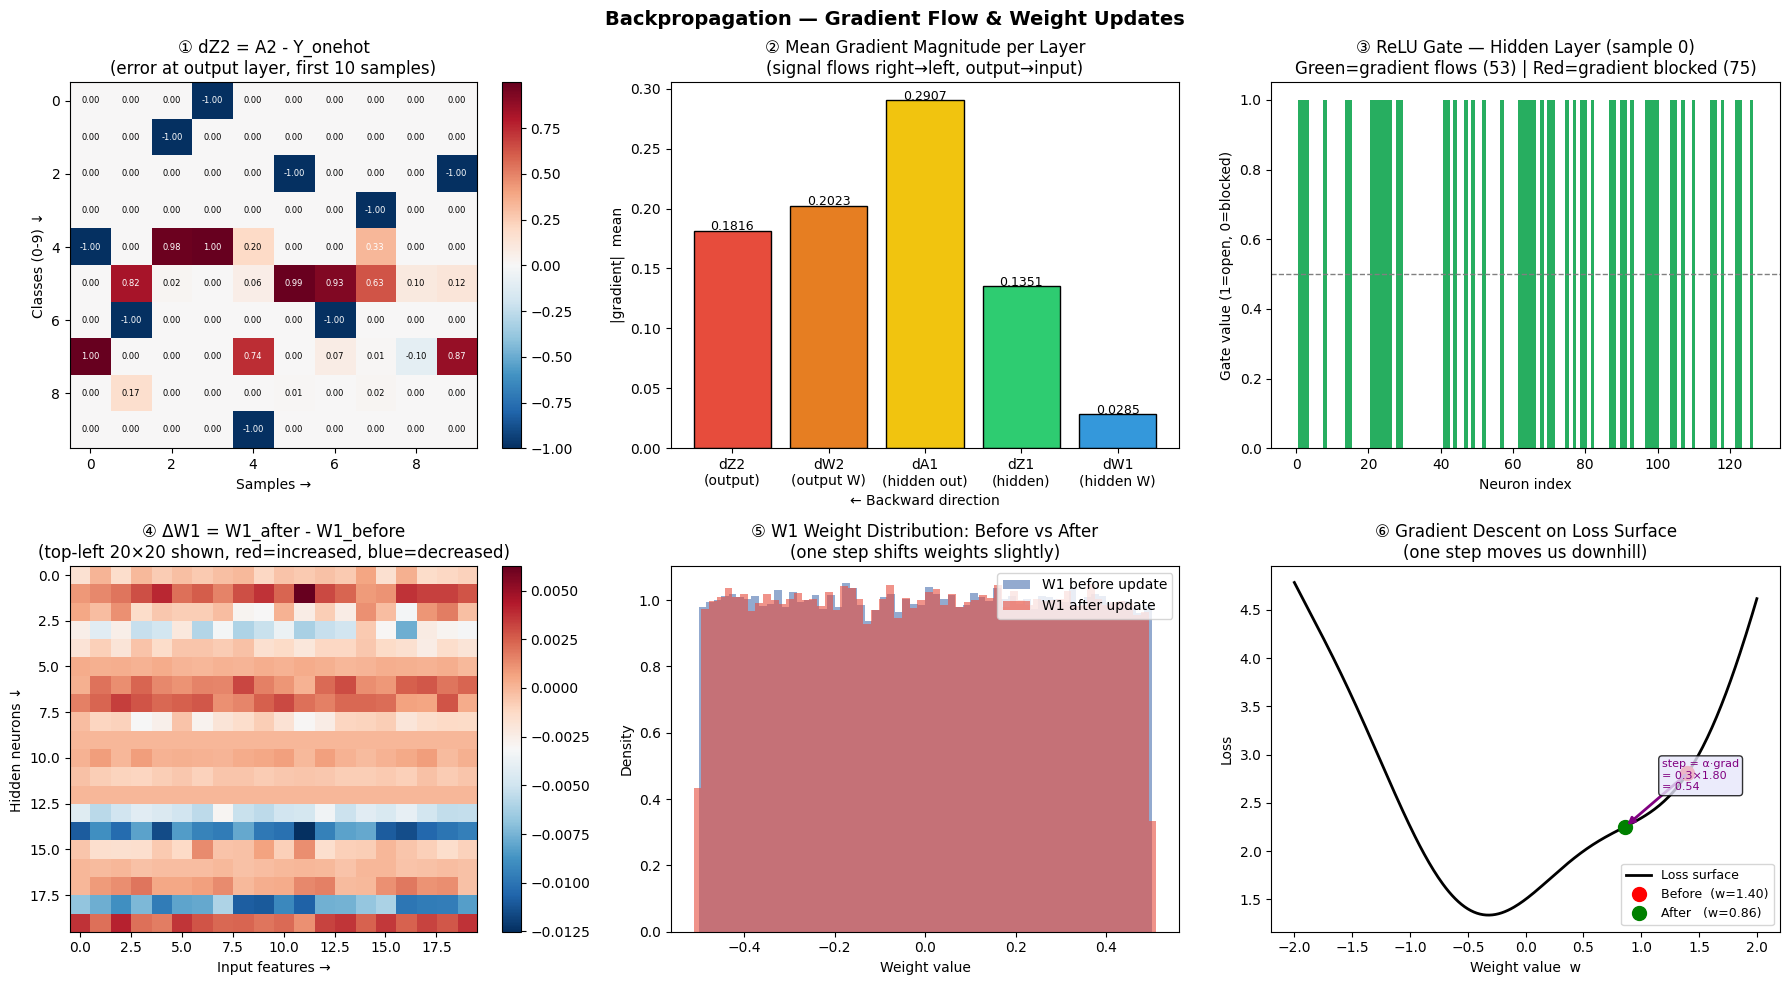

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Backpropagation — Gradient Flow & Weight Updates", fontsize=14, fontweight='bold')

# ── Plot 1: dZ2 — error signal at output layer ────────────────────────────────
ax = axes[0, 0]
im = ax.imshow(dZ2[:, :10], cmap='RdBu_r', aspect='auto')
ax.set_title("① dZ2 = A2 - Y_onehot\n(error at output layer, first 10 samples)")
ax.set_xlabel("Samples →")
ax.set_ylabel("Classes (0-9) ↓")
plt.colorbar(im, ax=ax)
for r in range(dZ2.shape[0]):
    for c in range(10):
        val = dZ2[r, c]
        ax.text(c, r, f"{val:.2f}", ha='center', va='center',
                fontsize=6, color='white' if abs(val) > 0.3 else 'black')

# ── Plot 2: Gradient magnitude at each layer — shows signal strength ──────────
ax = axes[0, 1]
grad_magnitudes = {
    'dZ2\n(output)':  np.mean(np.abs(dZ2)),
    'dW2\n(output W)': np.mean(np.abs(dW2)),
    'dA1\n(hidden out)': np.mean(np.abs(dA1)),
    'dZ1\n(hidden)':  np.mean(np.abs(dZ1)),
    'dW1\n(hidden W)': np.mean(np.abs(dW1)),
}
colors_g = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#3498db']
bars = ax.bar(grad_magnitudes.keys(), grad_magnitudes.values(), color=colors_g, edgecolor='black')
for bar, val in zip(bars, grad_magnitudes.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0002,
            f"{val:.4f}", ha='center', fontsize=9)
ax.set_title("② Mean Gradient Magnitude per Layer\n(signal flows right→left, output→input)")
ax.set_ylabel("|gradient|  mean")
ax.set_xlabel("← Backward direction")

# ── Plot 3: ReLU gate — which neurons blocked the gradient ────────────────────
ax = axes[0, 2]
gate = ReLU_derivative(nn_bp.Z1[:, 0])    # first sample, hidden layer
active = gate.sum()
ax.bar(range(len(gate)), gate,
       color=['#27ae60' if g > 0 else '#e74c3c' for g in gate],
       width=1.0, edgecolor='none')
ax.set_title(f"③ ReLU Gate — Hidden Layer (sample 0)\n"
             f"Green=gradient flows ({int(active)}) | Red=gradient blocked ({int(len(gate)-active)})")
ax.set_xlabel("Neuron index")
ax.set_ylabel("Gate value (1=open, 0=blocked)")
ax.axhline(0.5, color='gray', linestyle='--', lw=1)

# ── Plot 4: Weight change heatmap — W1 before vs after ────────────────────────
ax = axes[1, 0]
W1_after  = nn_bp.hidden.W.copy()
delta_W1  = W1_after[:20, :20] - W1_before[:20, :20]   # top-left 20x20 for clarity
im = ax.imshow(delta_W1, cmap='RdBu_r', aspect='auto')
ax.set_title("④ ΔW1 = W1_after - W1_before\n(top-left 20×20 shown, red=increased, blue=decreased)")
ax.set_xlabel("Input features →")
ax.set_ylabel("Hidden neurons ↓")
plt.colorbar(im, ax=ax)

# ── Plot 5: W1 distribution before vs after ───────────────────────────────────
ax = axes[1, 1]
ax.hist(W1_before.flatten(), bins=60, alpha=0.6, color='#4C72B0', label='W1 before update', density=True)
ax.hist(W1_after.flatten(),  bins=60, alpha=0.6, color='#e74c3c', label='W1 after update',  density=True)
ax.set_title("⑤ W1 Weight Distribution: Before vs After\n(one step shifts weights slightly)")
ax.set_xlabel("Weight value")
ax.set_ylabel("Density")
ax.legend()

# ── Plot 6: Loss landscape intuition ─────────────────────────────────────────
ax = axes[1, 2]
w_range = np.linspace(-2, 2, 300)
# Simulate a loss surface shaped like a bowl (parabola) for intuition
loss_surface = 0.8 * w_range**2 + 0.3 * np.sin(3 * w_range) + 1.5

# Current weight position and gradient step
w_current  = 1.4
loss_current = 0.8 * w_current**2 + 0.3 * np.sin(3 * w_current) + 1.5
grad_current = 1.6 * w_current + 0.9 * np.cos(3 * w_current)   # derivative

alpha_viz = 0.3
w_new      = w_current - alpha_viz * grad_current
loss_new   = 0.8 * w_new**2 + 0.3 * np.sin(3 * w_new) + 1.5

ax.plot(w_range, loss_surface, 'k-', lw=2, label='Loss surface')
ax.plot(w_current, loss_current, 'ro', markersize=10, label=f'Before  (w={w_current:.2f})')
ax.plot(w_new,     loss_new,     'go', markersize=10, label=f'After   (w={w_new:.2f})')
ax.annotate("", xy=(w_new, loss_new), xytext=(w_current, loss_current),
            arrowprops=dict(arrowstyle='-|>', color='purple', lw=2))
ax.text((w_current + w_new)/2 + 0.05, (loss_current + loss_new)/2 + 0.1,
        f"step = α·grad\n= {alpha_viz}×{grad_current:.2f}\n= {alpha_viz*grad_current:.2f}",
        fontsize=8, color='purple',
        bbox=dict(boxstyle='round', facecolor='lavender', alpha=0.8))
ax.set_title("⑥ Gradient Descent on Loss Surface\n(one step moves us downhill)")
ax.set_xlabel("Weight value  w")
ax.set_ylabel("Loss")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

---
## Cell 16 — The Training Loop

Everything we've built so far is one **iteration**:

```
forward(X) → loss → backward() → update weights
```

Training is just repeating this hundreds of times on real data.  
Each iteration, the weights get a small nudge. Over time, they converge to values that minimize the loss.

### One Epoch vs One Iteration
- **Iteration**: one forward + backward pass on a batch of samples  
- **Epoch**: one full pass through the entire dataset

We'll train on real MNIST data (the same `train.csv` from `code.ipynb`) and track loss + accuracy every 10 steps so we can watch the network learn in real time.

In [14]:
import pandas as pd

# ── Load & prepare MNIST data (same as code.ipynb) ────────────────────────────
data = pd.read_csv("train.csv")
data = np.array(data)
np.random.seed(42)
np.random.shuffle(data)

# Split: first 1000 for validation, rest for training
data_val   = data[:1000].T
Y_val      = data_val[0].astype(int)
X_val      = data_val[1:] / 255.0          # normalize pixels to [0, 1]

data_train = data[1000:].T
Y_train    = data_train[0].astype(int)
X_train    = data_train[1:] / 255.0

print(f"Training   : X={X_train.shape}  Y={Y_train.shape}")
print(f"Validation : X={X_val.shape}    Y={Y_val.shape}")
print(f"Classes    : {np.unique(Y_train)}")
print(f"Pixel range: [{X_train.min():.1f}, {X_train.max():.1f}]")

Training   : X=(784, 41000)  Y=(41000,)
Validation : X=(784, 1000)    Y=(1000,)
Classes    : [0 1 2 3 4 5 6 7 8 9]
Pixel range: [0.0, 1.0]


In [15]:
def accuracy(nn, X, Y):
    preds = nn.predict(X)
    return np.mean(preds == Y)


def train(nn, X, Y, X_val, Y_val, alpha=0.1, iterations=500):
    """
    Full training loop.
    Runs `iterations` steps of: forward → loss → backward → update.
    Records loss & accuracy every 10 steps.
    """
    history = {'iter': [], 'train_loss': [], 'train_acc': [], 'val_acc': []}

    for i in range(iterations):

        # ── Forward pass ──────────────────────────────────────────────────
        A2 = nn.forward(X)

        # ── Compute loss ──────────────────────────────────────────────────
        loss = cross_entropy_loss(A2, Y)

        # ── Backward pass + weight update ─────────────────────────────────
        backward(nn, X, Y, alpha)

        # ── Record every 10 steps ─────────────────────────────────────────
        if i % 10 == 0:
            tr_acc  = accuracy(nn, X, Y)
            val_acc = accuracy(nn, X_val, Y_val)
            history['iter'].append(i)
            history['train_loss'].append(loss)
            history['train_acc'].append(tr_acc)
            history['val_acc'].append(val_acc)
            print(f"iter {i:>4}  |  loss: {loss:.4f}  |  train acc: {tr_acc:.3f}  |  val acc: {val_acc:.3f}")

    return history


# ── Train ─────────────────────────────────────────────────────────────────────
np.random.seed(42)
nn_trained = NeuralNetwork(n_inputs=784, n_hidden=128, n_outputs=10)

history = train(nn_trained, X_train, Y_train, X_val, Y_val, alpha=0.1, iterations=500)

iter    0  |  loss: 8.9195  |  train acc: 0.129  |  val acc: 0.141
iter   10  |  loss: 1.9171  |  train acc: 0.557  |  val acc: 0.565
iter   20  |  loss: 1.2938  |  train acc: 0.665  |  val acc: 0.670
iter   30  |  loss: 1.0461  |  train acc: 0.720  |  val acc: 0.721
iter   40  |  loss: 0.9049  |  train acc: 0.751  |  val acc: 0.758
iter   50  |  loss: 0.8116  |  train acc: 0.774  |  val acc: 0.780
iter   60  |  loss: 0.7445  |  train acc: 0.790  |  val acc: 0.793
iter   70  |  loss: 0.6932  |  train acc: 0.803  |  val acc: 0.809
iter   80  |  loss: 0.6522  |  train acc: 0.814  |  val acc: 0.817
iter   90  |  loss: 0.6185  |  train acc: 0.823  |  val acc: 0.827
iter  100  |  loss: 0.5902  |  train acc: 0.830  |  val acc: 0.831
iter  110  |  loss: 0.5659  |  train acc: 0.837  |  val acc: 0.837
iter  120  |  loss: 0.5448  |  train acc: 0.842  |  val acc: 0.842
iter  130  |  loss: 0.5262  |  train acc: 0.847  |  val acc: 0.846
iter  140  |  loss: 0.5097  |  train acc: 0.851  |  val acc: 0

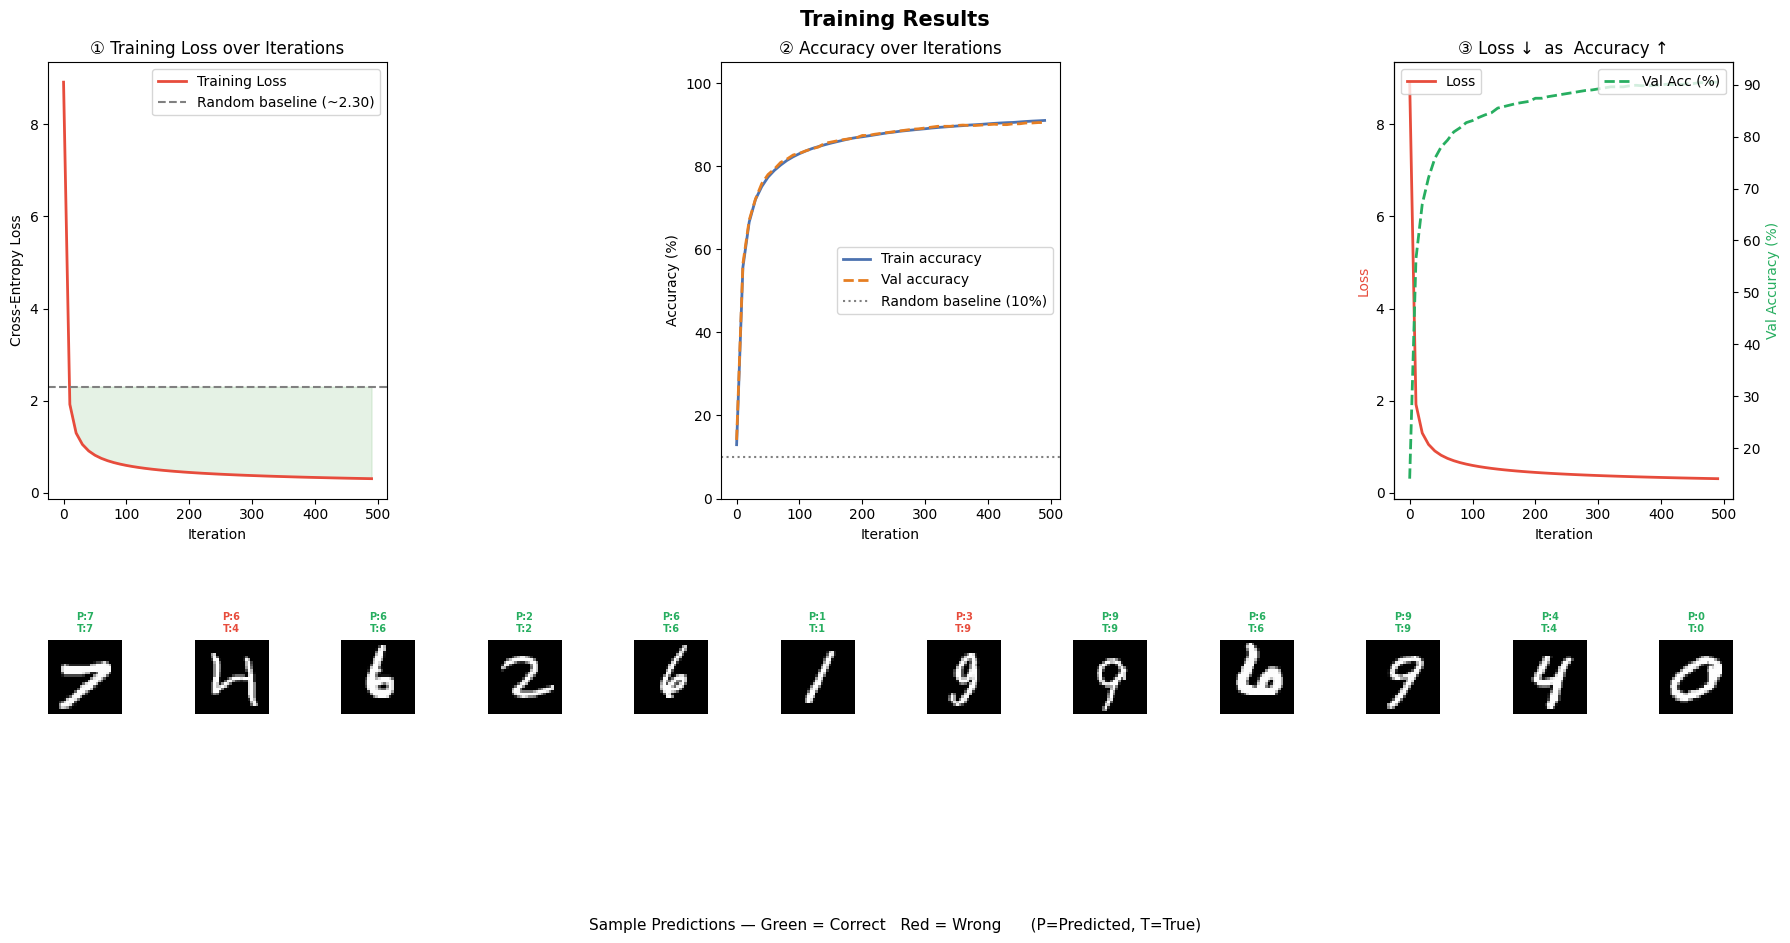


Final validation accuracy: 90.5%
Started at ~10% (random), reached 90.5% in 500 iterations


In [16]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Training Results", fontsize=15, fontweight='bold')

iters = history['iter']

# ── Plot 1: Loss curve ────────────────────────────────────────────────────────
ax = axes[0, 0]
ax.plot(iters, history['train_loss'], color='#e74c3c', lw=2, label='Training Loss')
ax.axhline(-np.log(0.1), color='gray', lw=1.5, linestyle='--', label='Random baseline (~2.30)')
ax.set_title("① Training Loss over Iterations")
ax.set_xlabel("Iteration")
ax.set_ylabel("Cross-Entropy Loss")
ax.legend()
ax.fill_between(iters, history['train_loss'], -np.log(0.1),
                where=[l < -np.log(0.1) for l in history['train_loss']],
                alpha=0.1, color='green', label='Below random')

# ── Plot 2: Accuracy curves ───────────────────────────────────────────────────
ax = axes[0, 1]
ax.plot(iters, [a * 100 for a in history['train_acc']], color='#4C72B0', lw=2, label='Train accuracy')
ax.plot(iters, [a * 100 for a in history['val_acc']],   color='#e67e22', lw=2, label='Val accuracy',   linestyle='--')
ax.axhline(10, color='gray', lw=1.5, linestyle=':', label='Random baseline (10%)')
ax.set_title("② Accuracy over Iterations")
ax.set_xlabel("Iteration")
ax.set_ylabel("Accuracy (%)")
ax.legend()
ax.set_ylim(0, 105)

# ── Plot 3: Loss vs Accuracy together (dual axis) ────────────────────────────
ax = axes[0, 2]
ax2_twin = ax.twinx()
ax.plot(iters,  history['train_loss'],                    color='#e74c3c', lw=2, label='Loss')
ax2_twin.plot(iters, [a*100 for a in history['val_acc']], color='#27ae60', lw=2, label='Val Acc (%)', linestyle='--')
ax.set_title("③ Loss ↓  as  Accuracy ↑")
ax.set_xlabel("Iteration")
ax.set_ylabel("Loss",           color='#e74c3c')
ax2_twin.set_ylabel("Val Accuracy (%)", color='#27ae60')
ax.legend(loc='upper left')
ax2_twin.legend(loc='upper right')

# ── Plot 4-6: Sample predictions on real digit images ─────────────────────────
# Pick 12 validation samples and show image + predicted vs true label
sample_indices = np.random.choice(X_val.shape[1], 12, replace=False)
X_samples = X_val[:, sample_indices]
Y_samples = Y_val[sample_indices]
probs_samples = nn_trained.forward(X_samples)
preds_samples = np.argmax(probs_samples, axis=0)

inner_grid = axes[1, 0].get_position()
fig.delaxes(axes[1, 0])
fig.delaxes(axes[1, 1])
fig.delaxes(axes[1, 2])

for idx in range(12):
    ax_img = fig.add_subplot(2, 12, 13 + idx)
    img = X_samples[:, idx].reshape(28, 28)
    ax_img.imshow(img, cmap='gray', interpolation='nearest')
    pred  = preds_samples[idx]
    true  = Y_samples[idx]
    color = '#27ae60' if pred == true else '#e74c3c'
    ax_img.set_title(f"P:{pred}\nT:{true}", fontsize=7, color=color, fontweight='bold')
    ax_img.axis('off')

fig.text(0.5, 0.06, "Sample Predictions — Green = Correct   Red = Wrong      (P=Predicted, T=True)",
         ha='center', fontsize=11)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.show()

final_val_acc = history['val_acc'][-1] * 100
print(f"\nFinal validation accuracy: {final_val_acc:.1f}%")
print(f"Started at ~10% (random), reached {final_val_acc:.1f}% in 500 iterations")